# Exploratory Data Analysis

Understanding the structure of the airline fare dataset to motivate the Graph Neural Network approach. Key questions: how is fare distributed? what does the route graph look like? are there seasonal and geographic patterns?

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datashader as ds
import datashader.transfer_functions as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# RdBu_r accent color for single-color plots
BLUE = '#4393c3'
RED  = '#d6604d'
# Quarter color key (RdBu_r-inspired: Q1=dark blue → Q4=dark red)
Q_COLORS = {'1': '#2166ac', '2': '#74add1', '3': '#f46d43', '4': '#d73027'}

In [68]:
DATA_PATH = '../../data/clean_data/T_DB1B_MARKET_CLEAN.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# 10% sample for visualizations — full dataset used for aggregate stats
df_sample = df.sample(frac=0.05, random_state=42).reset_index(drop=True)
print(f"\nSample for plots: {df_sample.shape[0]:,} rows")
df_sample.head()

Full dataset: 25,072,315 rows × 19 columns
Columns: ['YEAR', 'QUARTER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST', 'REPORTING_CARRIER', 'TICKET_CARRIER', 'OPERATING_CARRIER', 'BULK_FARE', 'PASSENGERS', 'MARKET_FARE', 'MARKET_DISTANCE', 'NONSTOP_MILES', 'MKT_GEO_TYPE', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']

Sample for plots: 1,253,616 rows


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
0,2024,3,13577,MYR,14100,PHL,PT,AA,PT,0.0,1.0,108.50,473.0,473.0,2,33.679699,-78.928299,39.871899,-75.241096
1,2024,3,12402,ITO,12173,HNL,WN,WN,WN,0.0,13.0,79.50,216.0,216.0,1,19.721399,-155.048004,21.320620,-157.924228
2,2024,3,14107,PHX,12173,HNL,OO,UA,99,0.0,1.0,298.50,2926.0,2917.0,1,33.434299,-112.012001,21.320620,-157.924228
3,2024,3,14027,PBI,14730,SDF,DL,DL,DL,0.0,1.0,515.00,866.0,857.0,2,26.683201,-80.095596,38.174400,-85.736000
4,2025,1,11066,CMH,14107,PHX,UA,UA,UA,0.0,1.0,463.64,1756.0,1670.0,2,39.998001,-82.891899,33.434299,-112.012001


## 2. Target Variable — MARKET_FARE

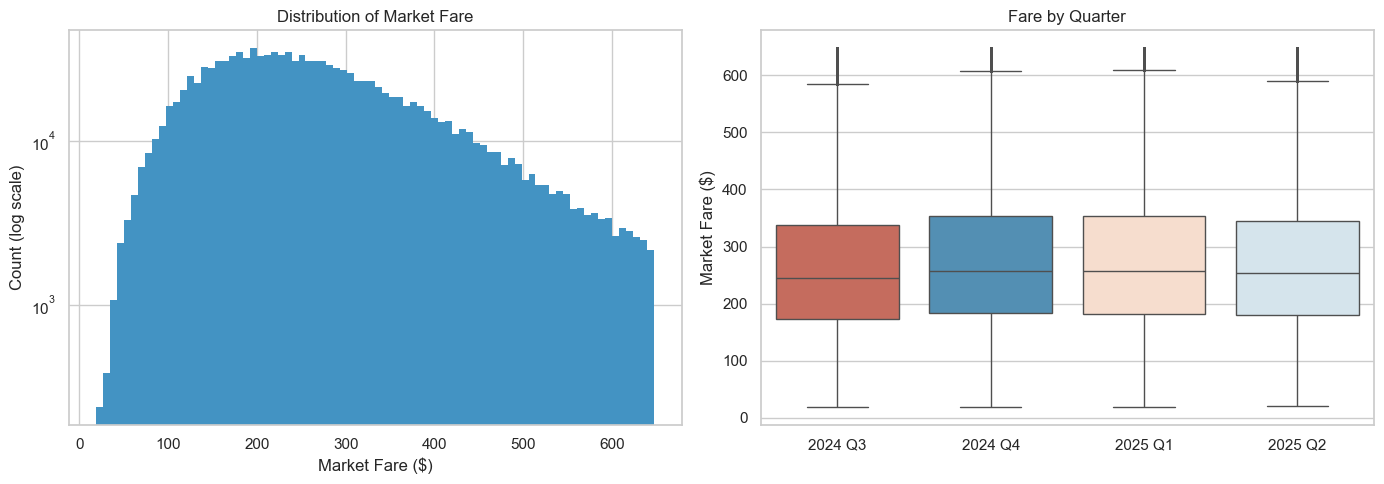

Fare statistics:
count    2.507232e+07
mean     2.726650e+02
std      1.236967e+02
min      1.901000e+01
50%      2.530000e+02
75%      3.470000e+02
95%      5.135000e+02
99%      6.090000e+02
max      6.472500e+02

Fares above $1,000: 0.0%


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution — log y scale
axes[0].hist(df_sample['MARKET_FARE'], bins=80, color=BLUE, edgecolor='none', log=True)
axes[0].set_xlabel('Market Fare ($)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Distribution of Market Fare')

# Box plot by quarter — seaborn supports `order`
df_sample['Quarter'] = df_sample['YEAR'].astype(str) + ' Q' + df_sample['QUARTER'].astype(str)
order = sorted(df_sample['Quarter'].unique())
sns.boxplot(data=df_sample, x='Quarter', y='MARKET_FARE', order=order,
            hue='Quarter', legend=False,
            ax=axes[1], palette='RdBu', fliersize=1)
axes[1].set_title('Fare by Quarter')
axes[1].set_xlabel('')
axes[1].set_ylabel('Market Fare ($)')

plt.tight_layout()
plt.show()

print("Fare statistics:")
print(df['MARKET_FARE'].describe(percentiles=[.5, .75, .95, .99]).to_string())
print(f"\nFares above $1,000: {(df['MARKET_FARE'] > 1000).mean():.1%}")

In [70]:
#checking on the outlier fares
df_sample.nlargest(29, 'MARKET_FARE')


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON,Quarter
131524,2025,2,15024,STT,11278,DCA,YX,DL,DL,0.0,1.0,647.25,2146.0,1588.0,1,18.337299,-64.973396,38.852100,-77.037697,2025 Q2
1241426,2025,1,12173,HNL,10397,ATL,UA,UA,UA,0.0,1.0,647.25,4537.0,4502.0,1,21.320620,-157.924228,33.636700,-84.428101,2025 Q1
544708,2024,3,14307,PVD,13485,MSN,DL,DL,99,0.0,1.0,647.24,1345.0,919.0,2,41.732601,-71.420403,43.139900,-89.337502,2024 Q3
526049,2024,4,12892,LAX,11193,CVG,AA,AA,99,0.0,1.0,647.21,2008.0,1900.0,2,33.942501,-118.407997,39.048801,-84.667801,2024 Q4
742689,2024,4,10821,BWI,12173,HNL,WN,WN,WN,0.0,1.0,647.20,4909.0,4855.0,1,39.175400,-76.668297,21.320620,-157.924228,2024 Q4
1115208,2024,3,12892,LAX,15304,TPA,DL,DL,DL,0.0,1.0,647.20,2158.0,2158.0,2,33.942501,-118.407997,27.975500,-82.533203,2024 Q3
1125362,2025,2,12264,IAD,12892,LAX,UA,UA,UA,0.0,1.0,647.20,2288.0,2288.0,2,38.944500,-77.455803,33.942501,-118.407997,2025 Q2
1216511,2024,3,14771,SFO,12217,HSV,OO,UA,99,0.0,1.0,647.20,2230.0,1990.0,2,37.618999,-122.375000,34.637199,-86.775101,2024 Q3
1208134,2024,4,11481,ECP,11278,DCA,DL,DL,DL,0.0,1.0,647.18,787.0,769.0,2,30.357106,-85.795414,38.852100,-77.037697,2024 Q4
1133623,2024,3,10397,ATL,10821,BWI,DL,DL,99,0.0,1.0,647.14,1132.0,577.0,2,33.636700,-84.428101,39.175400,-76.668297,2024 Q3


## 3. Graph Structure

Airports are nodes, routes are directed edges. Understanding the graph topology motivates the GNN — hub airports connect to many routes and influence neighboring pricing through competition.

Nodes (airports):       447
Edges (unique routes):  81,857
Avg routes per airport: 183.1


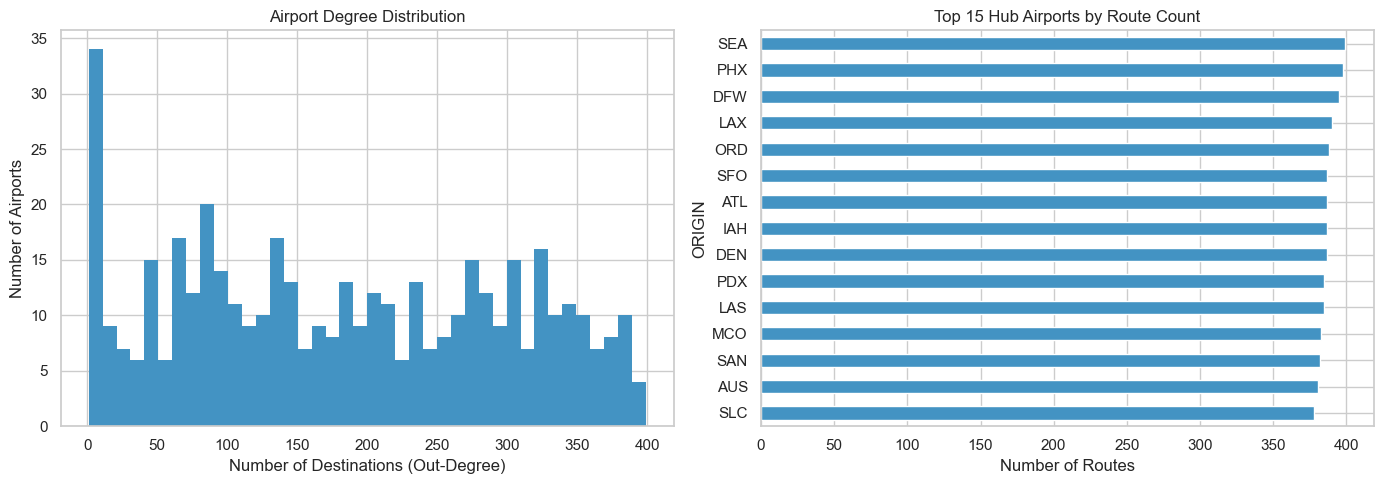

In [71]:
n_airports = df['ORIGIN'].nunique()
n_routes = df.groupby(['ORIGIN', 'DEST']).ngroups
print(f"Nodes (airports):       {n_airports:,}")
print(f"Edges (unique routes):  {n_routes:,}")
print(f"Avg routes per airport: {n_routes / n_airports:.1f}")

degree = df.groupby('ORIGIN')['DEST'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degree.values, bins=40, color=BLUE, edgecolor='none')
axes[0].set_xlabel('Number of Destinations (Out-Degree)')
axes[0].set_ylabel('Number of Airports')
axes[0].set_title('Airport Degree Distribution')

degree.head(15).plot(kind='barh', ax=axes[1], color=BLUE)
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of Routes')
axes[1].set_title('Top 15 Hub Airports by Route Count')

plt.tight_layout()
plt.show()

## 4. Geographic Analysis

Latitude/longitude are node features in the GNN. Distance correlates with fare but is far from a perfect predictor — especially for hub airports where competition suppresses prices.

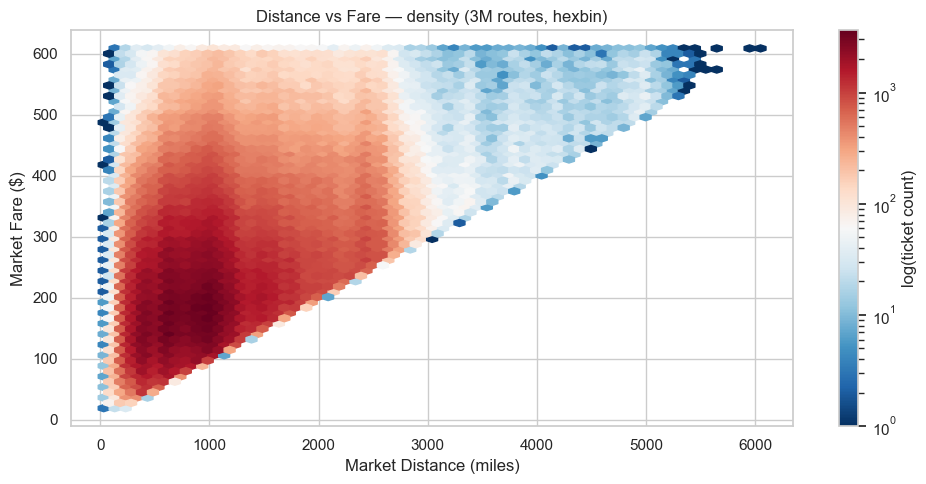

In [72]:
fare_cap = df_sample['MARKET_FARE'].quantile(0.99)
df_ds = df_sample[df_sample['MARKET_FARE'] <= fare_cap].copy()

fig, ax = plt.subplots(figsize=(10, 5))
hb = ax.hexbin(
    df_ds['MARKET_DISTANCE'], df_ds['MARKET_FARE'],
    gridsize=60, cmap='RdBu_r', bins='log',
    mincnt=1
)
plt.colorbar(hb, ax=ax, label='log(ticket count)')
ax.set_xlabel('Market Distance (miles)')
ax.set_ylabel('Market Fare ($)')
ax.set_title('Distance vs Fare — density (3M routes, hexbin)')
plt.tight_layout()
plt.show()

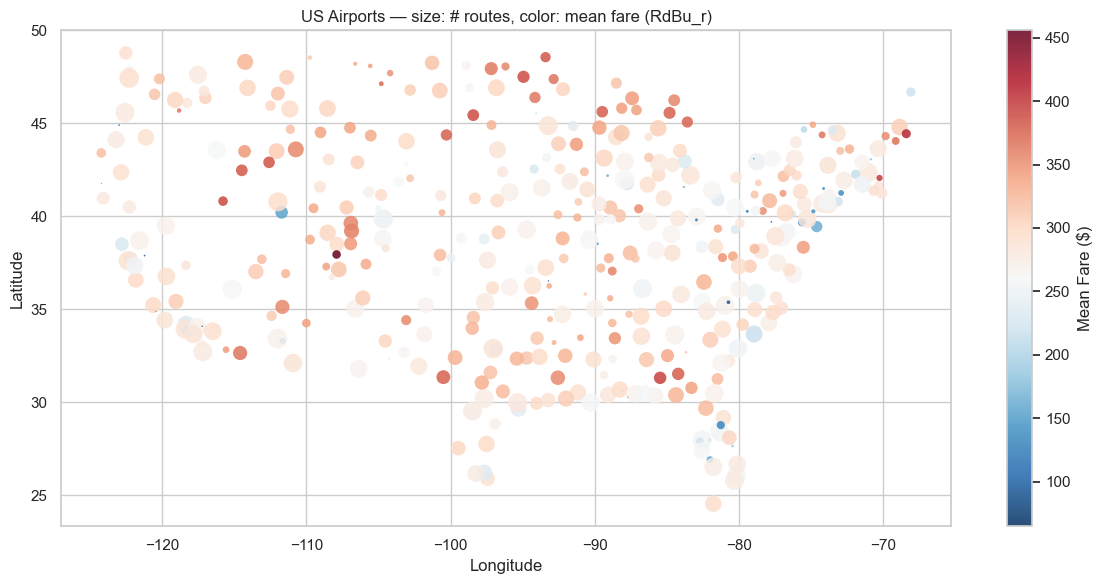

In [73]:
# --- US Airport Map: size = degree, color = mean fare (RdBu_r) ---
airport_stats = (
    df.groupby('ORIGIN')
    .agg(degree=('DEST', 'nunique'),
         mean_fare=('MARKET_FARE', 'mean'),
         lat=('ORIGIN_LAT', 'first'),
         lon=('ORIGIN_LON', 'first'))
    .reset_index()
)
us = airport_stats[airport_stats['lon'].between(-130, -65) & airport_stats['lat'].between(24, 50)]

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(us['lon'], us['lat'],
                s=us['degree'] * 0.5,
                c=us['mean_fare'], cmap='RdBu_r',
                alpha=0.85, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Mean Fare ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('US Airports — size: # routes, color: mean fare (RdBu_r)')
plt.tight_layout()
plt.show()

## 5. Seasonal Patterns

Fares vary by quarter — summer and holiday periods show different pricing. Quarter is included as a cyclic edge feature in the GNN.

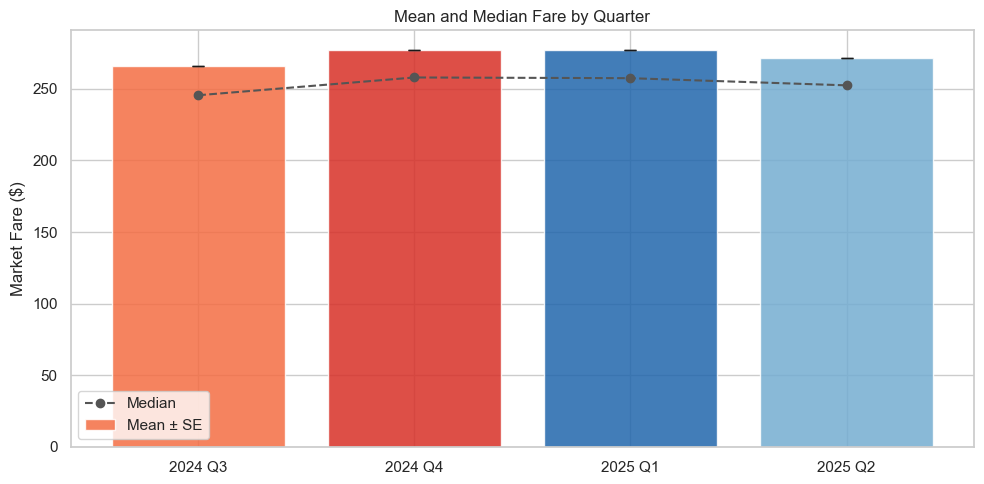

  label       mean  median        std
2024 Q3 265.774448  245.58 122.430795
2024 Q4 276.971383  258.00 124.871266
2025 Q1 276.897813  257.50 125.095847
2025 Q2 271.386448  252.50 122.185716


In [74]:
quarter_stats = (
    df.groupby(['YEAR', 'QUARTER'])['MARKET_FARE']
    .agg(mean='mean', median='median', std='std', n='count')
    .reset_index()
)
quarter_stats['label'] = quarter_stats['YEAR'].astype(str) + ' Q' + quarter_stats['QUARTER'].astype(str)

# Map each row to its RdBu_r quarter color
bar_colors = [Q_COLORS[str(q)] for q in quarter_stats['QUARTER']]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(quarter_stats))
ax.bar(x, quarter_stats['mean'], yerr=quarter_stats['std'] / np.sqrt(quarter_stats['n']),
       color=bar_colors, alpha=0.85, capsize=4, label='Mean ± SE')
ax.plot(x, quarter_stats['median'], 'o--', color='#555555', label='Median')
ax.set_xticks(list(x))
ax.set_xticklabels(quarter_stats['label'])
ax.set_ylabel('Market Fare ($)')
ax.set_title('Mean and Median Fare by Quarter')
ax.legend()
plt.tight_layout()
plt.show()

print(quarter_stats[['label', 'mean', 'median', 'std']].to_string(index=False))

## 6. Carrier Effects

Different carriers price routes differently. Carrier is encoded as an edge feature in the GNN.

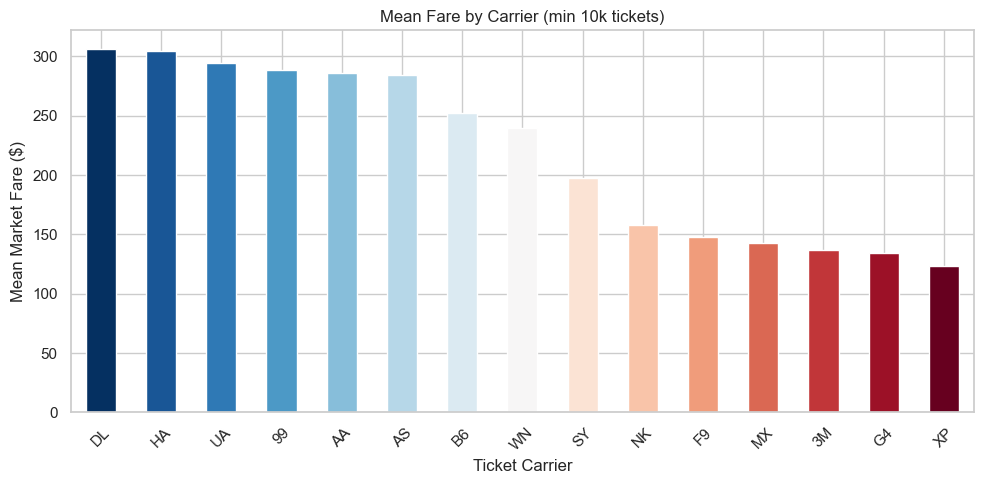

                 mean_fare  n_tickets
TICKET_CARRIER                       
DL              306.598689    5066845
HA              304.672632     148319
UA              294.173385    4485772
99              288.974022     371060
AA              286.085386    6082122
AS              284.334269    1180258
B6              252.378211     527007
WN              239.679442    5822426
SY              197.959849      38365
NK              157.552955     476693
F9              148.127227     444994
MX              142.550393     132332
3M              136.458062      11154
G4              134.010071     236723
XP              123.349807      47226


In [75]:
carrier_fare = (
    df.groupby('TICKET_CARRIER')['MARKET_FARE']
    .agg(mean_fare='mean', n_tickets='count')
    .query('n_tickets >= 10000')
    .sort_values('mean_fare', ascending=False)
    .head(15)
)

# Color bars by rank using RdBu_r (highest fare = red, lowest = blue)
n = len(carrier_fare)
cmap = plt.cm.RdBu_r
colors = [cmap(i / (n - 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(10, 5))
carrier_fare['mean_fare'].plot(kind='bar', ax=ax, color=colors)
ax.set_xlabel('Ticket Carrier')
ax.set_ylabel('Mean Market Fare ($)')
ax.set_title('Mean Fare by Carrier (min 10k tickets)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(carrier_fare.to_string())

## 7. Feature Correlations

Realizing shortfall of current data, feature engineering is important for neural network to learn.

In [76]:
# ── Distance-based ────────────────────────────────────────────────────────────
df_sample['fare_per_mile']   = df_sample['MARKET_FARE'] / df_sample['MARKET_DISTANCE']
df_sample['detour_ratio']    = df_sample['MARKET_DISTANCE'] / df_sample['NONSTOP_MILES']
df_sample['distance_squared']= df_sample['MARKET_DISTANCE'] ** 2

# ── Geography-based: hub flags ────────────────────────────────────────────────
HUBS = {'ATL', 'ORD', 'DFW', 'LAX', 'JFK', 'DEN', 'SFO', 'LAS', 'SEA', 'MIA'}
df_sample['origin_is_hub'] = df_sample['ORIGIN'].isin(HUBS).astype(int)
df_sample['dest_is_hub']   = df_sample['DEST'].isin(HUBS).astype(int)
df_sample['both_hubs']     = ((df_sample['origin_is_hub'] == 1) & 
                               (df_sample['dest_is_hub']   == 1)).astype(int)

# ── Geography-based: region clusters via k-means on lat/lon ──────────────────
coords = df_sample[['ORIGIN_LAT', 'ORIGIN_LON']].values
df_sample['origin_region'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(coords)

coords_dest = df_sample[['DEST_LAT', 'DEST_LON']].values
df_sample['dest_region'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(coords_dest)

# ── Route-based ───────────────────────────────────────────────────────────────
df_sample['is_short_haul']      = (df_sample['MARKET_DISTANCE'] < 500).astype(int)
df_sample['number_of_carriers'] = df_sample.groupby(['ORIGIN','DEST','YEAR','QUARTER'])['TICKET_CARRIER'].transform('nunique')
df_sample['route_total_passengers'] = df_sample.groupby(['ORIGIN','DEST','YEAR','QUARTER'])['PASSENGERS'].transform('sum')
df_sample['OHE_TICKET_CARRIER'] = df_sample['TICKET_CARRIER'].astype('category').cat.codes
df_sample['OHE_REPORTING_CARRIER'] = df_sample['REPORTING_CARRIER'].astype('category').cat.codes
df_sample['OHE_ORIGIN'] = df_sample['ORIGIN'].astype('category').cat.codes
df_sample['OHE_DEST'] = df_sample['DEST'].astype('category').cat.codes

# ── Interaction terms ─────────────────────────────────────────────────────────
df_sample['distance_x_detour']  = df_sample['MARKET_DISTANCE'] * df_sample['detour_ratio']

# ── Seasonality (if QUARTER exists) ──────────────────────────────────────────
if 'QUARTER' in df_sample.columns:
    df_sample['is_summer']    = df_sample['QUARTER'].isin([2, 3]).astype(int)
    df_sample['is_holiday_q'] = df_sample['QUARTER'].isin([1, 4]).astype(int)

# ── Updated feature list ──────────────────────────────────────────────────────
new_features = [
    'MARKET_DISTANCE', 'NONSTOP_MILES', 'PASSENGERS',
    'fare_per_mile', 'detour_ratio', 'distance_squared',
    'origin_is_hub', 'dest_is_hub', 'both_hubs',
    'origin_region', 'dest_region',
    'is_short_haul', 'distance_x_detour', 
    'number_of_carriers', 'route_total_passengers'
]
if 'QUARTER' in df_sample.columns:
    new_features += ['QUARTER', 'is_summer', 'is_holiday_q']

print(f"Total features: {len(new_features)}")
print(df_sample[new_features].head())

Total features: 18
   MARKET_DISTANCE  NONSTOP_MILES  PASSENGERS  fare_per_mile  detour_ratio  \
0            473.0          473.0         1.0       0.229387      1.000000   
1            216.0          216.0        13.0       0.368056      1.000000   
2           2926.0         2917.0         1.0       0.102016      1.003085   
3            866.0          857.0         1.0       0.594688      1.010502   
4           1756.0         1670.0         1.0       0.264032      1.051497   

   distance_squared  origin_is_hub  dest_is_hub  both_hubs  origin_region  \
0          223729.0              0            0          0              1   
1           46656.0              0            0          0              4   
2         8561476.0              0            0          0              0   
3          749956.0              0            0          0              1   
4         3083536.0              0            0          0              2   

   dest_region  is_short_haul  distance_x_detour 

In [77]:
# add macro level data by quarter and year
jet_fuel = pd.read_csv('../../data/rawdata/JET_FUEL.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
real_dpi = pd.read_csv('../../data/rawdata/REAL_DPI.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
unrate   = pd.read_csv('../../data/rawdata/UNRATE.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
air_cpi  = pd.read_csv('../../data/rawdata/AIR_CPI.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})

df_sample = df_sample.merge(jet_fuel, on=['YEAR', 'QUARTER'], how='left')
df_sample = df_sample.merge(real_dpi, on=['YEAR', 'QUARTER'], how='left')
df_sample = df_sample.merge(unrate,   on=['YEAR', 'QUARTER'], how='left')
df_sample = df_sample.merge(air_cpi,  on=['YEAR', 'QUARTER'], how='left')

print(df_sample[['YEAR', 'QUARTER', 'JET_FUEL_DPG', '2017_dollars_DPI', 'UNRATE_pct', 'AIR_CPI_1982-1984=100']].drop_duplicates(['YEAR','QUARTER']))

    YEAR  QUARTER  JET_FUEL_DPG  2017_dollars_DPI  UNRATE_pct  \
0   2024        3         2.205           17755.3         4.2   
4   2025        1         2.229           17943.1         4.1   
5   2025        2         1.999           18025.3         4.2   
13  2024        4         2.069           17843.3         4.1   

    AIR_CPI_1982-1984=100  
0                 246.421  
4                 260.010  
5                 257.254  
13                265.944  


In [78]:
#sanity check after merge
df_sample.head()

,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON,Quarter,fare_per_mile,detour_ratio,distance_squared,origin_is_hub,dest_is_hub,both_hubs,origin_region,dest_region,is_short_haul,number_of_carriers,route_total_passengers,OHE_TICKET_CARRIER,OHE_REPORTING_CARRIER,OHE_ORIGIN,OHE_DEST,distance_x_detour,is_summer,is_holiday_q,JET_FUEL_DPG,2017_dollars_DPI,UNRATE_pct,AIR_CPI_1982-1984=100
0,2024,3,13577,MYR,14100,PHL,PT,AA,PT,0.0,1.0,108.50,473.0,473.0,2,33.679699,-78.928299,39.871899,-75.241096,2024 Q3,0.229387,1.000000,223729.0,0,0,0,1,1,1,4,45.0,4,16,288,312,473.000000,1,0,2.205,17755.3,4.2,246.421
1,2024,3,12402,ITO,12173,HNL,WN,WN,WN,0.0,13.0,79.50,216.0,216.0,1,19.721399,-155.048004,21.320620,-157.924228,2024 Q3,0.368056,1.000000,46656.0,0,0,0,4,2,1,3,387.0,21,20,208,176,216.000000,1,0,2.205,17755.3,4.2,246.421
2,2024,3,14107,PHX,12173,HNL,OO,UA,99,0.0,1.0,298.50,2926.0,2917.0,1,33.434299,-112.012001,21.320620,-157.924228,2024 Q3,0.102016,1.003085,8561476.0,0,0,0,0,2,0,5,78.0,19,15,316,176,2935.027768,1,0,2.205,17755.3,4.2,246.421
3,2024,3,14027,PBI,14730,SDF,DL,DL,DL,0.0,1.0,515.00,866.0,857.0,2,26.683201,-80.095596,38.174400,-85.736000,2024 Q3,0.594688,1.010502,749956.0,0,0,0,1,1,0,3,10.0,7,6,308,366,875.094516,1,0,2.205,17755.3,4.2,246.421
4,2025,1,11066,CMH,14107,PHX,UA,UA,UA,0.0,1.0,463.64,1756.0,1670.0,2,39.998001,-82.891899,33.434299,-112.012001,2025 Q1,0.264032,1.051497,3083536.0,0,0,0,2,0,0,4,127.0,19,19,88,313,1846.428743,0,1,2.229,17943.1,4.1,260.010


In [80]:
#FEES AND SALARY FOR AIRLINE in thousands of dollars
p6_2025_q1 = pd.read_csv('../../data/rawdata/P6_2025_Q1.csv')
p6_2025_q2 = pd.read_csv('../../data/rawdata/P6_2025_Q2.csv')
p6_2025_q3 = pd.read_csv('../../data/rawdata/P6_2024_Q3.csv')
p6_2025_q4 = pd.read_csv('../../data/rawdata/P6_2024_Q4.csv')

form41 = pd.concat([p6_2025_q1, p6_2025_q2, p6_2025_q3, p6_2025_q4], ignore_index=True)

for col in ['SALARIES', 'BENEFITS', 'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']:
    form41[col] = form41[col] * 1000

#group data from different regions
form41_agg = (
    form41.groupby(['UNIQUE_CARRIER', 'YEAR', 'QUARTER'])
    [['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']]
    .sum()
    .reset_index()
)

df_sample = df_sample.merge(
    form41_agg,
    left_on =['TICKET_CARRIER', 'YEAR', 'QUARTER'],
    right_on=['UNIQUE_CARRIER',  'YEAR', 'QUARTER'],
    how='left'
).drop(columns='UNIQUE_CARRIER')

In [82]:
#sanity check after merge
df_sample.head()

,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON,Quarter,fare_per_mile,detour_ratio,distance_squared,origin_is_hub,dest_is_hub,both_hubs,origin_region,dest_region,is_short_haul,number_of_carriers,route_total_passengers,OHE_TICKET_CARRIER,OHE_REPORTING_CARRIER,OHE_ORIGIN,OHE_DEST,distance_x_detour,is_summer,is_holiday_q,JET_FUEL_DPG,2017_dollars_DPI,UNRATE_pct,AIR_CPI_1982-1984=100,SALARIES_BENEFITS,AIRCRAFT_FUEL,LANDING_FEES,RENTALS
0,2024,3,13577,MYR,14100,PHL,PT,AA,PT,0.0,1.0,108.50,473.0,473.0,2,33.679699,-78.928299,39.871899,-75.241096,2024 Q3,0.229387,1.000000,223729.0,0,0,0,1,1,1,4,45.0,4,16,288,312,473.000000,1,0,2.205,17755.3,4.2,246.421,4.347508e+09,2.355899e+09,276249560.0,887191900.0
1,2024,3,12402,ITO,12173,HNL,WN,WN,WN,0.0,13.0,79.50,216.0,216.0,1,19.721399,-155.048004,21.320620,-157.924228,2024 Q3,0.368056,1.000000,46656.0,0,0,0,4,2,1,3,387.0,21,20,208,176,216.000000,1,0,2.205,17755.3,4.2,246.421,3.235859e+09,1.417207e+09,191196000.0,374183000.0
2,2024,3,14107,PHX,12173,HNL,OO,UA,99,0.0,1.0,298.50,2926.0,2917.0,1,33.434299,-112.012001,21.320620,-157.924228,2024 Q3,0.102016,1.003085,8561476.0,0,0,0,0,2,0,5,78.0,19,15,316,176,2935.027768,1,0,2.205,17755.3,4.2,246.421,4.606352e+09,2.675828e+09,346745810.0,584019470.0
3,2024,3,14027,PBI,14730,SDF,DL,DL,DL,0.0,1.0,515.00,866.0,857.0,2,26.683201,-80.095596,38.174400,-85.736000,2024 Q3,0.594688,1.010502,749956.0,0,0,0,1,1,0,3,10.0,7,6,308,366,875.094516,1,0,2.205,17755.3,4.2,246.421,4.897224e+09,2.475281e+09,279286000.0,688393000.0
4,2025,1,11066,CMH,14107,PHX,UA,UA,UA,0.0,1.0,463.64,1756.0,1670.0,2,39.998001,-82.891899,33.434299,-112.012001,2025 Q1,0.264032,1.051497,3083536.0,0,0,0,2,0,0,4,127.0,19,19,88,313,1846.428743,0,1,2.229,17943.1,4.1,260.010,4.419047e+09,2.389827e+09,330694770.0,595242850.0


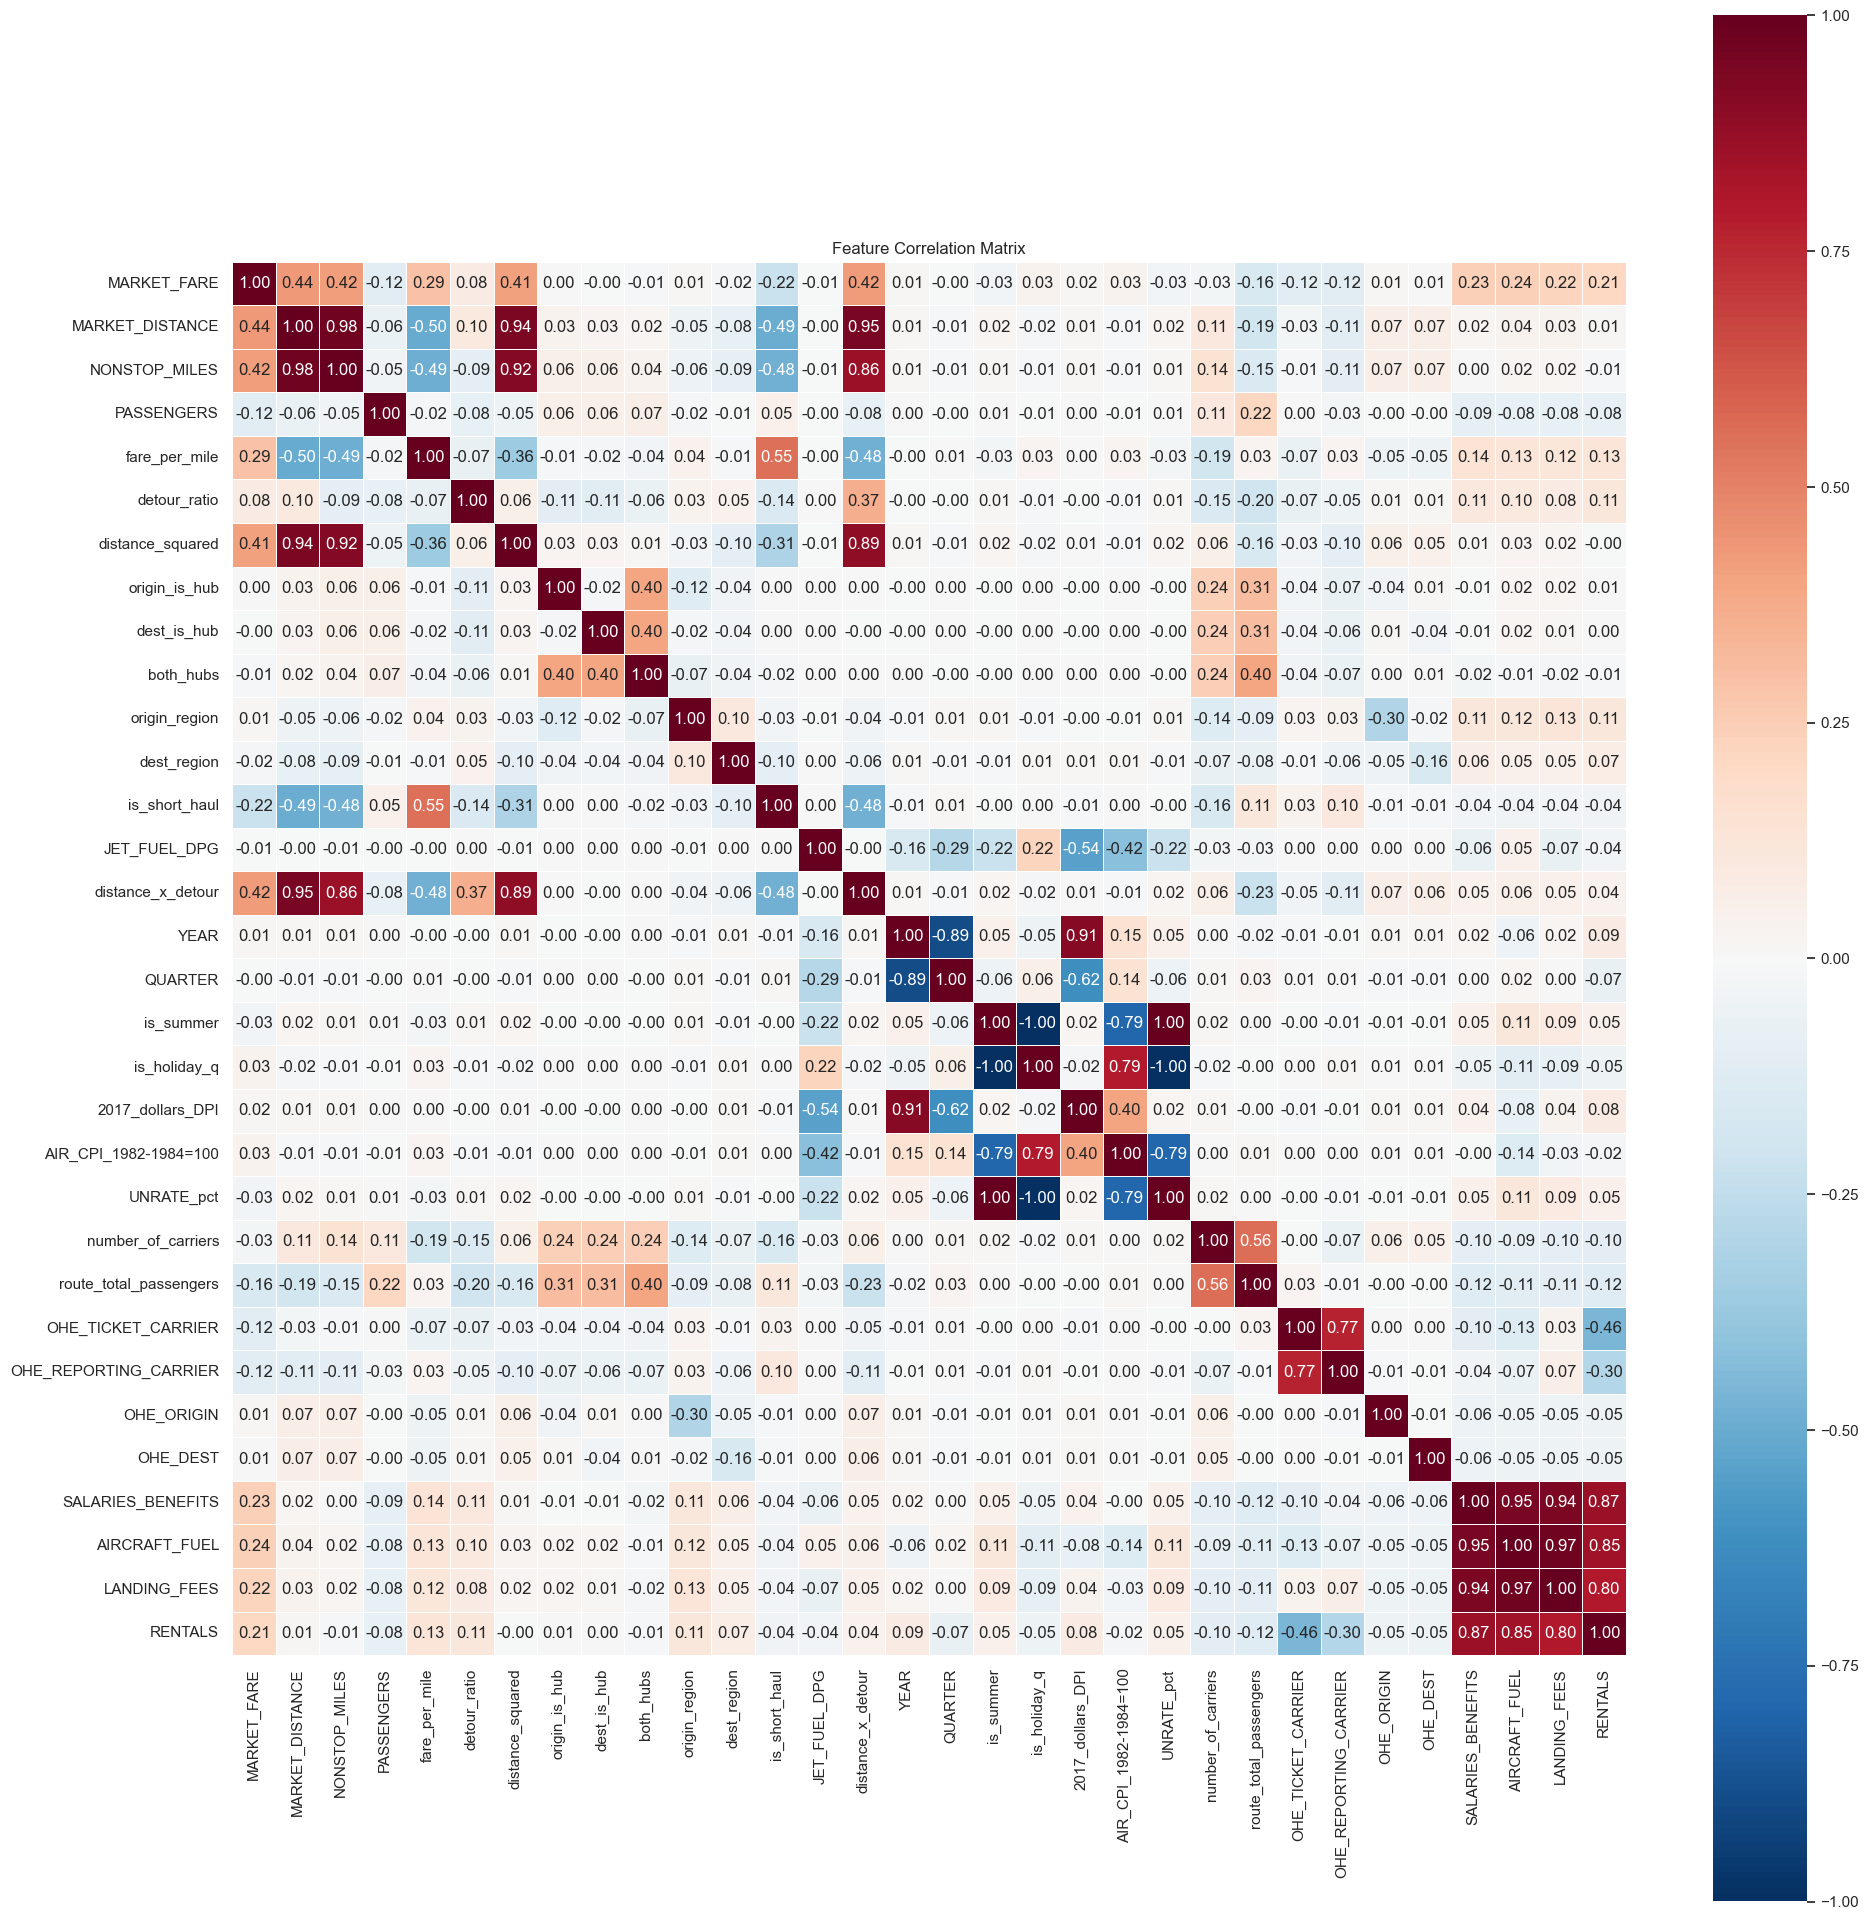

,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,PASSENGERS,fare_per_mile,detour_ratio,distance_squared,origin_is_hub,dest_is_hub,both_hubs,origin_region,dest_region,is_short_haul,JET_FUEL_DPG,distance_x_detour,YEAR,QUARTER,is_summer,is_holiday_q,2017_dollars_DPI,AIR_CPI_1982-1984=100,UNRATE_pct,number_of_carriers,route_total_passengers,OHE_TICKET_CARRIER,OHE_REPORTING_CARRIER,OHE_ORIGIN,OHE_DEST,SALARIES_BENEFITS,AIRCRAFT_FUEL,LANDING_FEES,RENTALS
MARKET_FARE,1.000000,0.436898,0.419825,-0.115660,0.292530,0.083627,0.409197,0.003262,-0.001617,-0.010944,0.010196,-0.018286,-0.224638,-0.006222,0.424613,0.010246,-0.003235,-0.031879,0.031879,0.015176,0.034333,-0.031879,-0.026730,-0.160056,-0.116472,-0.115776,0.008124,0.006811,0.234412,0.236706,0.219585,0.206363
MARKET_DISTANCE,0.436898,1.000000,0.976164,-0.063863,-0.502227,0.095719,0.938445,0.033062,0.030965,0.022091,-0.052738,-0.080103,-0.494014,-0.004184,0.951924,0.009916,-0.009443,0.016006,-0.016006,0.008261,-0.011345,0.016006,0.108804,-0.190956,-0.030157,-0.113207,0.068197,0.067471,0.021977,0.037321,0.033425,0.012662
NONSTOP_MILES,0.419825,0.976164,1.000000,-0.045055,-0.491158,-0.094015,0.919981,0.057016,0.055241,0.038311,-0.058672,-0.088957,-0.477300,-0.005274,0.864769,0.010856,-0.009584,0.013835,-0.013835,0.009785,-0.008580,0.013835,0.144192,-0.149325,-0.014442,-0.105026,0.065656,0.065860,0.000088,0.017800,0.016641,-0.011501
PASSENGERS,-0.115660,-0.063863,-0.045055,1.000000,-0.022392,-0.084778,-0.052000,0.057029,0.057877,0.069228,-0.017401,-0.007188,0.049791,-0.000892,-0.081512,0.001046,-0.001376,0.006775,-0.006775,0.000452,-0.005641,0.006775,0.108335,0.216304,0.001006,-0.028898,-0.002178,-0.001107,-0.089547,-0.080926,-0.084175,-0.083174
fare_per_mile,0.292530,-0.502227,-0.491158,-0.022392,1.000000,-0.073679,-0.361636,-0.013625,-0.017034,-0.036947,0.041527,-0.010250,0.550269,-0.004307,-0.478625,-0.001345,0.006312,-0.025768,0.025768,0.003807,0.026377,-0.025768,-0.194326,0.027149,-0.065769,0.026428,-0.053097,-0.053290,0.138589,0.130737,0.120440,0.125988
detour_ratio,0.083627,0.095719,-0.094015,-0.084778,-0.073679,1.000000,0.055427,-0.109176,-0.110791,-0.063896,0.034087,0.046275,-0.141482,0.002843,0.366687,-0.001162,-0.001363,0.009871,-0.009871,-0.003389,-0.010990,0.009871,-0.149333,-0.198811,-0.073806,-0.046878,0.012970,0.010026,0.105303,0.096010,0.083152,0.113922
distance_squared,0.409197,0.938445,0.919981,-0.052000,-0.361636,0.055427,1.000000,0.030025,0.028194,0.014367,-0.034276,-0.099440,-0.306725,-0.005144,0.887447,0.008306,-0.007906,0.019980,-0.019980,0.006831,-0.014605,0.019980,0.055257,-0.163986,-0.033870,-0.095931,0.055363,0.053863,0.007944,0.026224,0.020974,-0.000062
origin_is_hub,0.003262,0.033062,0.057016,0.057029,-0.013625,-0.109176,0.030025,1.000000,-0.018435,0.397786,-0.123964,-0.043247,0.001875,0.002120,0.002166,-0.002307,0.001544,-0.002733,0.002733,-0.002532,0.001026,-0.002733,0.237670,0.306464,-0.038898,-0.071104,-0.039572,0.014523,-0.005870,0.020626,0.016055,0.006587
dest_is_hub,-0.001617,0.030965,0.055241,0.057877,-0.017034,-0.110791,0.028194,-0.018435,1.000000,0.398396,-0.018646,-0.036219,0.003615,0.000689,-0.000514,-0.003332,0.003190,-0.002635,0.002635,-0.002799,0.001702,-0.002635,0.243928,0.309973,-0.037458,-0.062719,0.013434,-0.036963,-0.007604,0.018185,0.013835,0.003920
both_hubs,-0.010944,0.022091,0.038311,0.069228,-0.036947,-0.063896,0.014367,0.397786,0.398396,1.000000,-0.074422,-0.039375,-0.022059,0.000108,0.001853,0.000432,-0.000063,-0.003467,0.003467,0.000737,0.003192,-0.003467,0.244976,0.396984,-0.044145,-0.069223,0.004460,0.005813,-0.024456,-0.009505,-0.015984,-0.009277


In [84]:
num_cols = ['MARKET_FARE', 'MARKET_DISTANCE', 'NONSTOP_MILES', 'PASSENGERS',
    'fare_per_mile', 'detour_ratio', 'distance_squared',
    'origin_is_hub', 'dest_is_hub', 'both_hubs',
    'origin_region', 'dest_region',
    'is_short_haul', 'JET_FUEL_DPG',
    'distance_x_detour', 'YEAR', 'QUARTER', 
    'is_summer', 'is_holiday_q', '2017_dollars_DPI', 'AIR_CPI_1982-1984=100',
    'UNRATE_pct', 'number_of_carriers', 'route_total_passengers', 'OHE_TICKET_CARRIER',
    'OHE_REPORTING_CARRIER', 'OHE_ORIGIN', 'OHE_DEST', 
    'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS'
]

corr = df_sample[num_cols].corr()

fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
df_sample[num_cols].corr()

## 8. Route-Level Fare Variance

The same route (ORIGIN → DEST) has significant fare variance across quarters and carriers. This motivates using temporal and graph-contextual features rather than simple distance-based regression.

Routes with ≥20 observations: 39,440

Within-route fare std dev:
count    39440.000000
mean       104.769730
std         18.058088
min          9.047297
25%         96.366691
50%        106.363279
75%        115.871853
max        181.112309


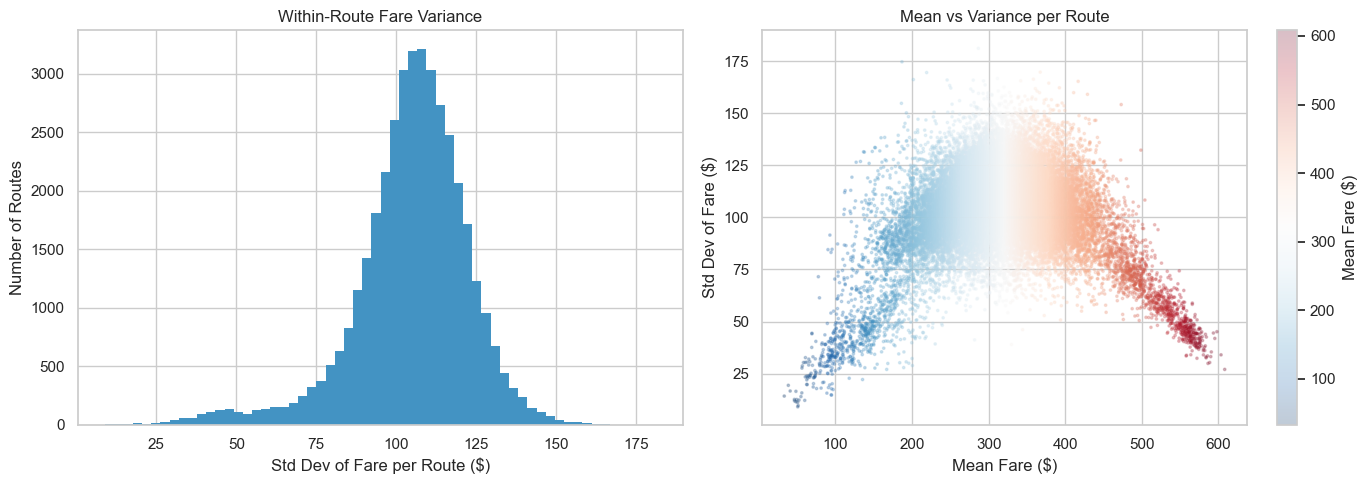

In [85]:
route_stats = (
    df.groupby(['ORIGIN', 'DEST'])['MARKET_FARE']
    .agg(mean_fare='mean', std_fare='std', n_obs='count')
    .query('n_obs >= 20')
    .reset_index()
)

print(f"Routes with ≥20 observations: {len(route_stats):,}")
print(f"\nWithin-route fare std dev:")
print(route_stats['std_fare'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(route_stats['std_fare'].dropna(), bins=60, color=BLUE, edgecolor='none')
axes[0].set_xlabel('Std Dev of Fare per Route ($)')
axes[0].set_ylabel('Number of Routes')
axes[0].set_title('Within-Route Fare Variance')

sc = axes[1].scatter(route_stats['mean_fare'], route_stats['std_fare'],
                     c=route_stats['mean_fare'], cmap='RdBu_r',
                     alpha=0.25, s=3)
plt.colorbar(sc, ax=axes[1], label='Mean Fare ($)')
axes[1].set_xlabel('Mean Fare ($)')
axes[1].set_ylabel('Std Dev of Fare ($)')
axes[1].set_title('Mean vs Variance per Route')

plt.tight_layout()
plt.show()